# Data parsing and exploration for learnedcache

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
import csv
import glob
from pathlib import Path

In [14]:
def parse_log_to_csv(input_filepath, output_filepath):
    """
    Parses a log file line-by-line and writes directly to a CSV 
    """
    with open(input_filepath, 'r') as infile:
        first_line = infile.readline()
        if not first_line:
            print("The file is empty.")
            return

        def parse_line(line):
            return dict(item.split('=') for item in line.strip().split() if '=' in item)

        initial_data = parse_line(first_line)
        fieldnames = list(initial_data.keys())

        with open(output_filepath, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            
            writer.writerow(initial_data)

            for line in infile:
                if line.strip():
                    row_data = parse_line(line)
                    writer.writerow(row_data)

def transform_logs_to_csvs(input_pattern):
    """
    Parses multiple log files matching the input pattern and writes each to a corresponding CSV file.
    """
    filepaths = glob.glob(input_pattern)
    for filepath in filepaths:
        parse_log_to_csv(filepath, Path(filepath).with_suffix('.csv'))

In [15]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    """
    Reads multiple CSV files and concatenates them into a single dataframe.
    """
    filepaths = glob.glob(file_pattern)
    dataframes = [pd.read_csv(filepath) for filepath in filepaths]
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    return combined_df

In [18]:
transform_logs_to_csvs('data/fileserver/*.log')

In [19]:
df = read_csvs_to_dataframe('data/fileserver/*access.csv')

In [ ]:
df.head()

,t,d,i,o,s,z,f
0,0,0:3,265289728,12582958,0,67641540608,1000
1,0,0:3,265289728,12582958,0,67641540608,1000
2,0,0:3,265289728,12582958,0,67641540608,1000
3,0,0:3,265289728,12621856,0,67641540608,1000
4,54843,0:3,265289728,12582958,0,67641540608,1100


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21136516 entries, 0 to 21136515
Data columns (total 7 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   t       int64 
 1   d       object
 2   i       int64 
 3   o       int64 
 4   s       int64 
 5   z       int64 
 6   f       int64 
dtypes: int64(6), object(1)
memory usage: 1.1+ GB


In [21]:
pd.set_option('display.precision', 5)
df.describe()

,t,i,o,s,z,f
count,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07
mean,2.38889e+09,1.26616e+08,1.87051e+06,5.47916e-01,3.21737e+10,2.17830e+06
std,6.07509e+09,1.32076e+08,2.28498e+06,4.97699e-01,3.37802e+10,2.07882e+07
min,0.00000e+00,1.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,1.00000e+03
25%,2.29230e+04,9.21258e+05,2.00000e+01,0.00000e+00,1.56332e+05,1.03100e+03
50%,1.29360e+07,9.25723e+05,6.62000e+02,1.00000e+00,4.81240e+05,4.00200e+03
75%,1.45910e+09,2.65290e+08,3.67029e+06,1.00000e+00,6.76415e+10,1.50156e+05
max,7.84853e+10,2.65290e+08,1.59599e+07,1.00000e+00,6.76415e+10,4.16784e+08


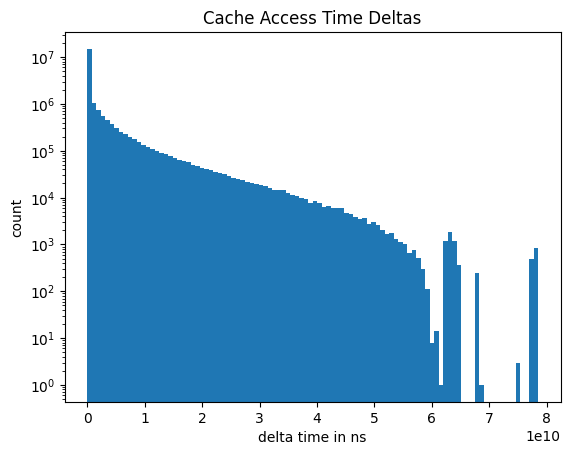

In [22]:
df['t'].plot(title='Cache Access Time Deltas', ylabel='count', xlabel="delta time in ns", kind='hist', bins=100)
plt.yscale('log')
plt.show()

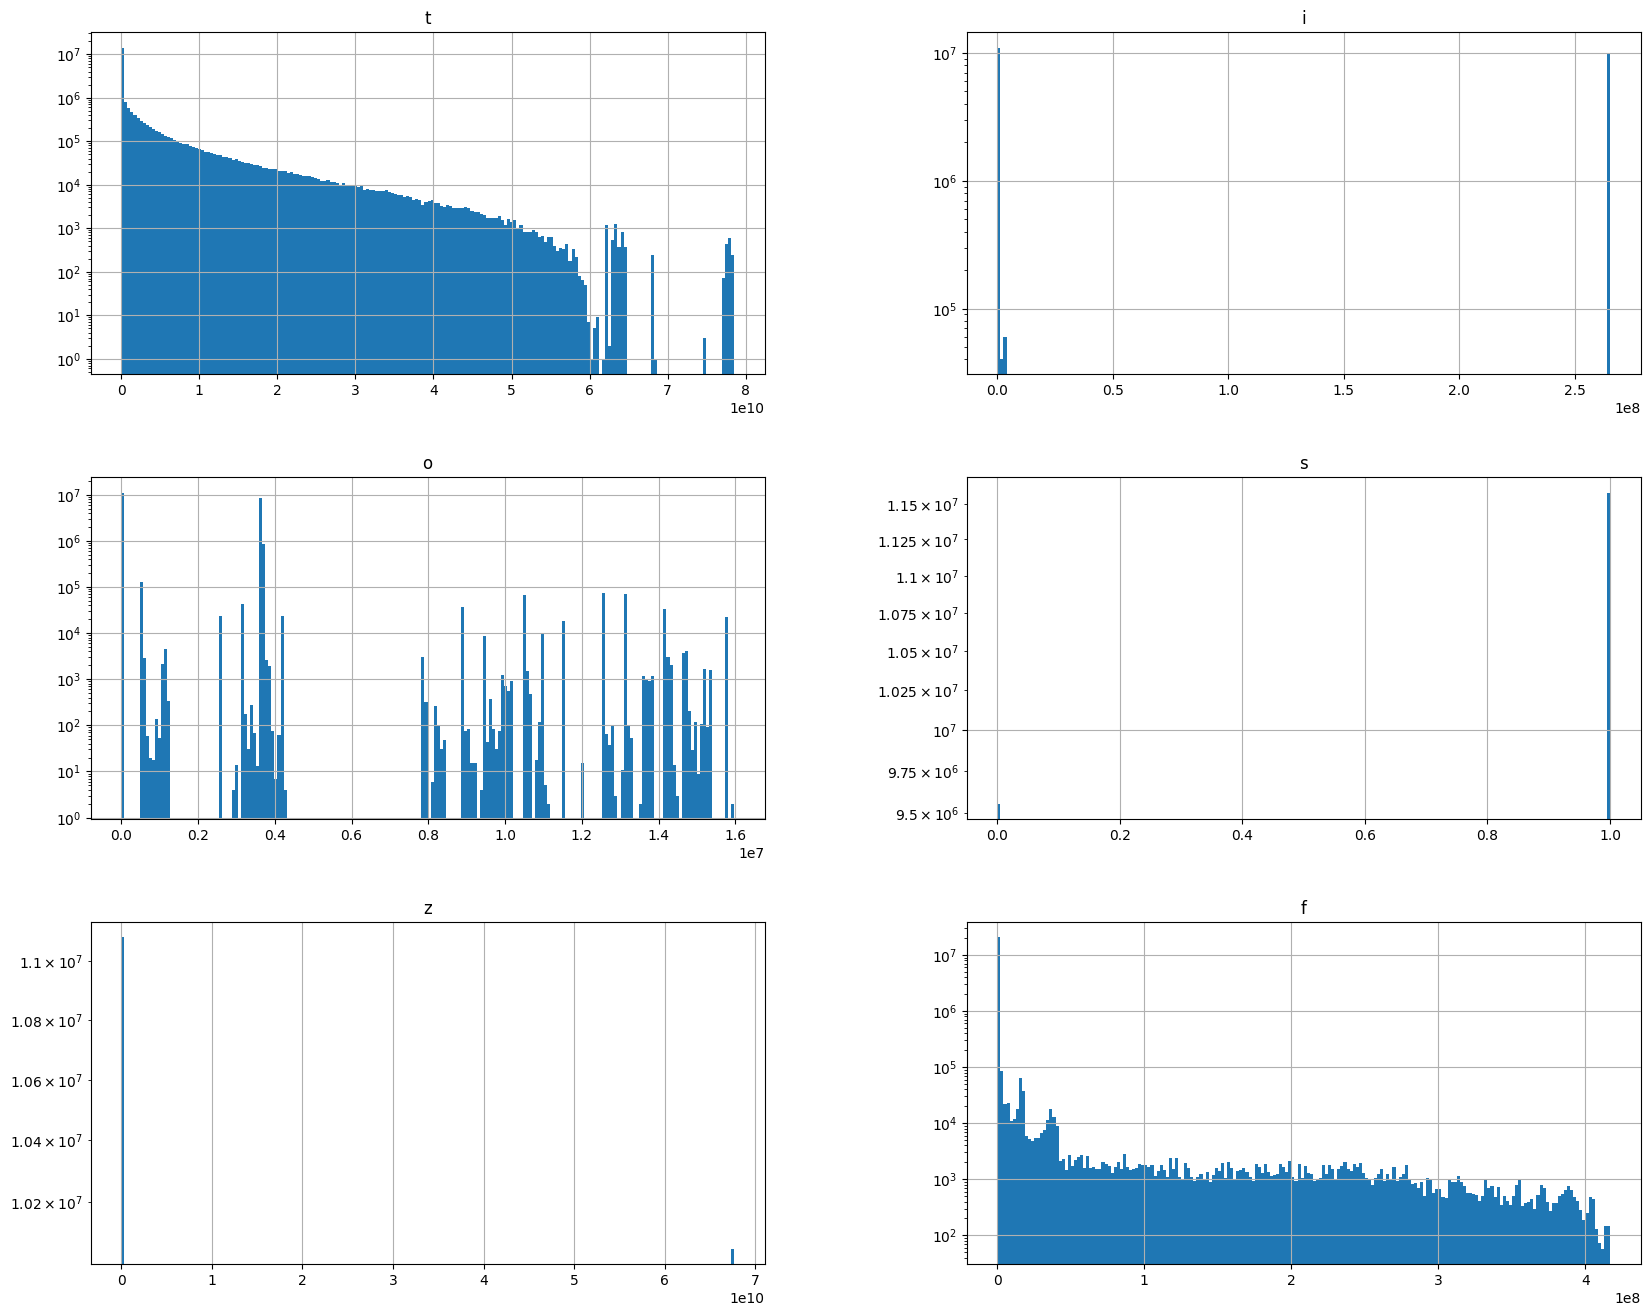

In [23]:
df.hist(figsize=(20,16), bins=200, log=True)
plt.show()

In [26]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = 'ordinal',
    strategy: str = 'quantile',
    subsample: int | None = None,
    random_state: int | None = None
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    """
    Train a KBinsDiscretizer on the training dataset and return the transformed dataframe.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training dataset to fit and transform
    n_bins : int, default=5
        Number of bins to produce. Must be >= 2.
    encode : {'onehot', 'onehot-dense', 'ordinal'}, default='ordinal'
        Method used to encode the transformed result.
        - 'onehot': Encode the transformed result with one-hot encoding
        - 'onehot-dense': Same as 'onehot' but returns dense array
        - 'ordinal': Return the bin identifier encoded as an integer value
    strategy : {'uniform', 'quantile', 'kmeans'}, default='quantile'
        Strategy used to define the widths of the bins.
        - 'uniform': All bins have identical widths
        - 'quantile': All bins have the same number of points
        - 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster
    subsample : int or None, default=None
        Maximum number of samples used to fit the model. If None, all samples are used.
    random_state : int or None, default=None
        Random state for reproducibility when using 'kmeans' strategy.
    
    Returns
    -------
    tuple[pd.DataFrame, KBinsDiscretizer]
        A tuple containing:
        - Transformed dataframe with discretized values
        - Fitted KBinsDiscretizer object for future transformations
    
    Examples
    --------
    >>> import pandas as pd
    >>> X_train = pd.DataFrame({'feature1': [1, 2, 3, 4, 5], 'feature2': [10, 20, 30, 40, 50]})
    >>> X_transformed, discretizer = train_and_transform_discretizer(X_train, n_bins=3)
    >>> print(X_transformed)
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state
    )

    X_transformed = discretizer.fit_transform(X_train)
    
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index
    )
    
    return X_transformed_df, discretizer


In [41]:
featureset_df, discretizer = train_and_transform_discretizer(df[['t', 'z', 'f']], n_bins=10, strategy='quantile')
featureset_df.head()

/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/jaydenq/projects/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/jaydenq/projects/learnedcache/.

,t,z,f
0,0.0,5.0,0.0
1,0.0,5.0,0.0
2,0.0,5.0,0.0
3,0.0,5.0,0.0
4,0.0,5.0,0.0


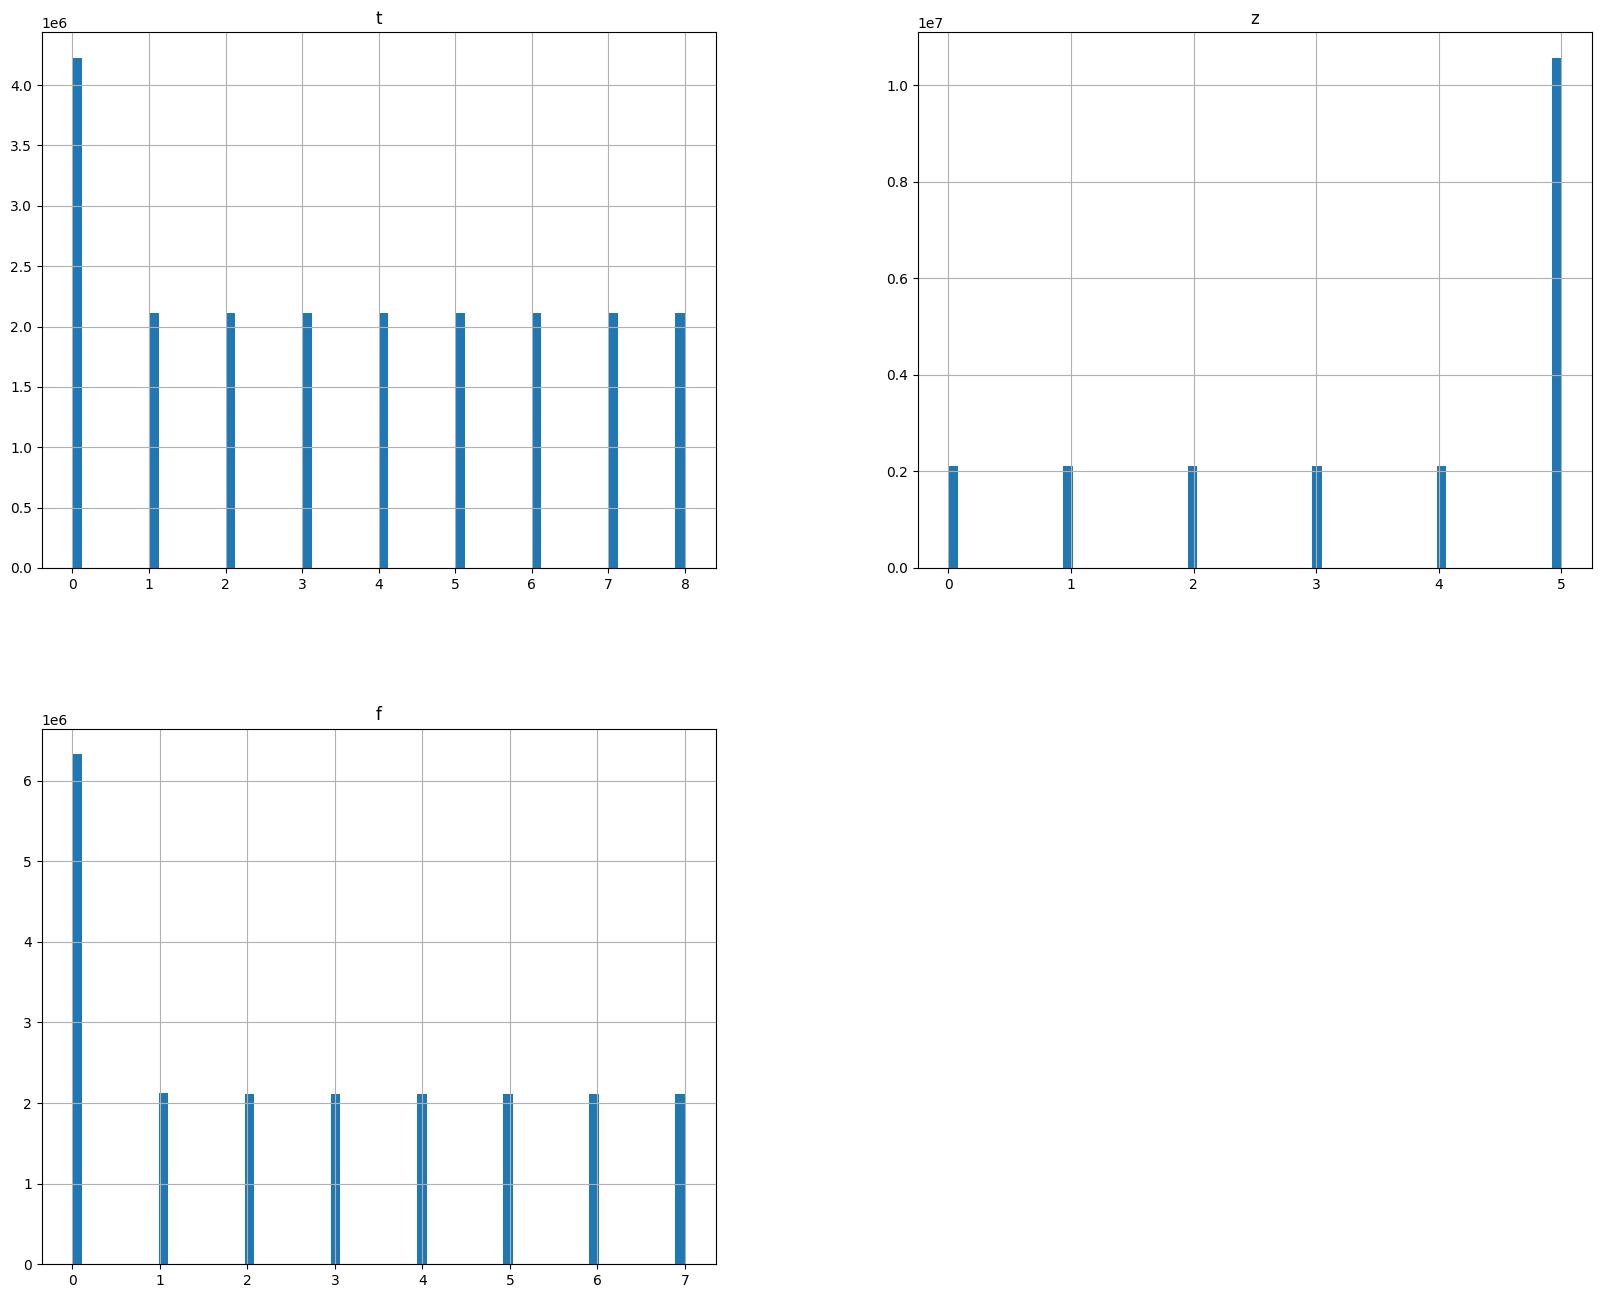

In [42]:
featureset_df.hist(figsize=(20,16), bins = 64)
plt.show()

In [43]:
discretizer.bin_edges_

array([array([0.00000000e+00, 3.00600000e+03, 8.51900000e+04, 1.07916900e+06,
              1.29359545e+07, 8.49938500e+07, 7.34659388e+08, 2.56361531e+09,
              7.45798276e+09, 7.84852536e+10])                               ,
       array([0.00000000e+00, 5.92720000e+04, 1.25947000e+05, 1.88844000e+05,
              2.71175000e+05, 4.81240000e+05, 6.76415406e+10])               ,
       array([1.00000000e+03, 1.14000000e+03, 1.71700000e+03, 4.00200000e+03,
              3.38780000e+04, 8.37975000e+04, 1.68365000e+05, 2.17781000e+05,
              4.16784003e+08])                                               ],
      dtype=object)